# Building the full LLM: MLA + MoE from scratch

Every earlier notebook built one brick. This notebook stacks them into a working
**character-level language model** that trains on Tiny Shakespeare and generates text.

The recipe is a small GPT-style decoder where:

- **attention** is the **Multi-Head Latent Attention (MLA)** with RoPE from notebook 05, and
- the **feed-forward** sublayer is the **Sparse Mixture of Experts** from notebook 06.

$$
\text{logits} = \text{Head}\Big(\text{LayerNorm}\big(\underbrace{(\text{MLA}+\text{MoE})\ \text{block}}_{\times\,N}(\text{Embed}(x))\big)\Big)
$$

We assemble it, train it, watch the loss fall, and sample some Shakespeare.

## The architecture

Each **transformer block** applies two sublayers with **pre-LayerNorm** and **residual
connections** (the green skip arrows): first MLA, then MoE. Residuals add the block input
back to its output, which keeps gradients flowing and makes deep stacks trainable. We stack
`N` of these, then a final LayerNorm and a Linear **head** that produces one score per
vocabulary character.

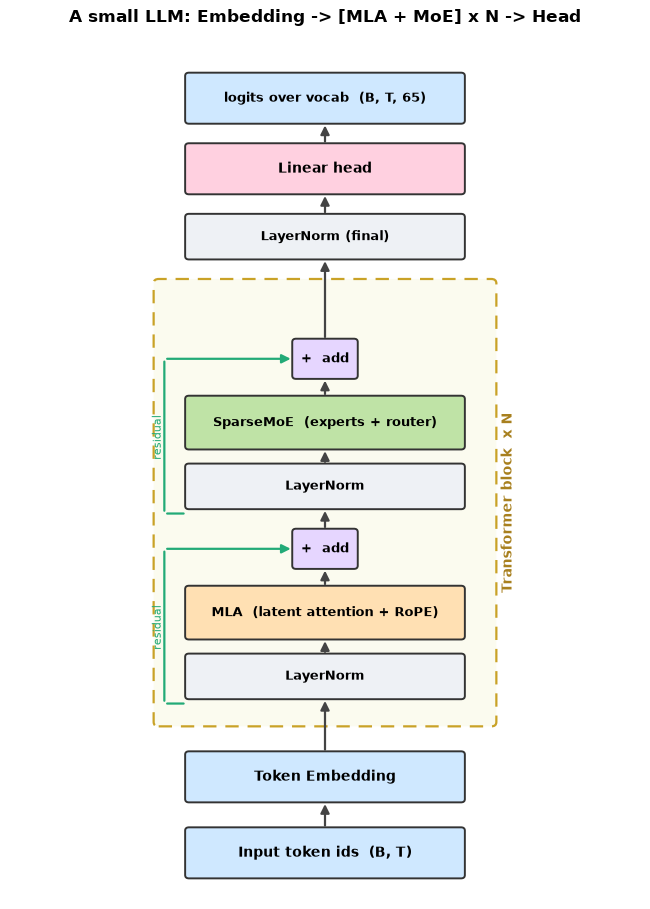

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _b(ax,x,y,w,h,t,fc,fs=10):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.02,rounding_size=0.06",fc=fc,ec="#333",lw=1.4))
    ax.text(x+w/2,y+h/2,t,ha="center",va="center",fontsize=fs,weight="bold")
def _a(ax,p1,p2,c="#444",lw=1.6):
    ax.add_patch(FancyArrowPatch(p1,p2,arrowstyle="-|>",mutation_scale=13,color=c,lw=lw))
def _line(ax,p1,p2,c="#2a7",lw=1.6):
    ax.add_patch(FancyArrowPatch(p1,p2,arrowstyle="-",color=c,lw=lw))

fig,ax=plt.subplots(figsize=(6.6,9.2)); ax.axis("off"); ax.set_xlim(0,10); ax.set_ylim(0,16)
cx,w=5,4.4
_b(ax,cx-w/2,0.4,w,0.9,"Input token ids  (B, T)","#cfe8ff")
_b(ax,cx-w/2,1.8,w,0.9,"Token Embedding","#cfe8ff"); _a(ax,(cx,1.3),(cx,1.8))
ax.add_patch(FancyBboxPatch((cx-w/2-0.5,3.2),w+1.0,8.2,boxstyle="round,pad=0.02,rounding_size=0.08",fc="#fbfbef",ec="#c9a227",lw=1.6,ls=(0,(6,4))))
ax.text(cx+w/2+0.7,7.3,"Transformer block  x N",rotation=90,va="center",ha="center",color="#a8801f",weight="bold")
_b(ax,cx-w/2,3.7,w,0.8,"LayerNorm","#eef1f5",9)
_b(ax,cx-w/2,4.8,w,0.95,"MLA  (latent attention + RoPE)","#ffe0b3",9)
_b(ax,cx-0.5,6.1,1.0,0.7,"+  add","#e6d6ff",9)
_b(ax,cx-w/2,7.2,w,0.8,"LayerNorm","#eef1f5",9)
_b(ax,cx-w/2,8.3,w,0.95,"SparseMoE  (experts + router)","#bfe3a6",9)
_b(ax,cx-0.5,9.6,1.0,0.7,"+  add","#e6d6ff",9)
_a(ax,(cx,2.7),(cx,3.7)); _a(ax,(cx,4.5),(cx,4.8)); _a(ax,(cx,5.75),(cx,6.1))
_a(ax,(cx,6.8),(cx,7.2)); _a(ax,(cx,8.0),(cx,8.3)); _a(ax,(cx,9.25),(cx,9.6))
_line(ax,(cx-w/2,3.6),(cx-w/2-0.35,3.6)); _line(ax,(cx-w/2-0.35,3.6),(cx-w/2-0.35,6.45)); _a(ax,(cx-w/2-0.35,6.45),(cx-0.5,6.45),c="#2a7")
_line(ax,(cx-w/2,7.1),(cx-w/2-0.35,7.1)); _line(ax,(cx-w/2-0.35,7.1),(cx-w/2-0.35,9.95)); _a(ax,(cx-w/2-0.35,9.95),(cx-0.5,9.95),c="#2a7")
ax.text(cx-w/2-0.55,5.0,"residual",rotation=90,color="#2a7",fontsize=8,va="center")
ax.text(cx-w/2-0.55,8.5,"residual",rotation=90,color="#2a7",fontsize=8,va="center")
_a(ax,(cx,10.3),(cx,11.8)); _b(ax,cx-w/2,11.8,w,0.8,"LayerNorm (final)","#eef1f5",9)
_b(ax,cx-w/2,13.0,w,0.9,"Linear head","#ffd0e0"); _a(ax,(cx,12.6),(cx,13.0))
_b(ax,cx-w/2,14.3,w,0.9,"logits over vocab  (B, T, 65)","#cfe8ff",9); _a(ax,(cx,13.9),(cx,14.3))
ax.set_title("A small LLM: Embedding -> [MLA + MoE] x N -> Head",weight="bold")
plt.tight_layout(); plt.show()

## Setup and data

Load Tiny Shakespeare, build the character vocabulary, split into train/val, and define
`get_batch`, which cuts random `(input, target)` pairs. The target is the input shifted by
one character, because the model is trained to **predict the next character**.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

block_size = 32     # context length (tokens per sequence)
batch_size = 16     # sequences per batch

def get_batch(split):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])   # shifted by one
    return x, y

print("vocab size:", vocab_size, "| train tokens:", len(train_data), "| val tokens:", len(val_data))

vocab size: 65 | train tokens: 1003854 | val tokens: 111540


## The attention: MLA with RoPE (from notebook 05)

Same class as notebook 05. It compresses keys/values into a small latent, decouples the
rotary (position) path, and returns `(output, cache)`. Inside the model we use only the
output.

In [3]:
def build_cos_sin(positions, dim, base=10000.0):
    inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
    freqs = positions[:, None].float() * inv_freq[None, :]
    emb = torch.cat([freqs, freqs], dim=-1)
    return emb.cos(), emb.sin()

def rotate_half(x):
    x1, x2 = x[..., : x.shape[-1] // 2], x[..., x.shape[-1] // 2:]
    return torch.cat([-x2, x1], dim=-1)

def apply_rope(x, cos, sin):
    return x * cos[None, :, None, :] + rotate_half(x) * sin[None, :, None, :]

class MLA(nn.Module):
    def __init__(self, d_model, n_heads, kv_latent_dim, rope_dim, base=10000.0):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.rope_dim = rope_dim
        self.base = base
        self.W_q   = nn.Linear(d_model, d_model, bias=False)
        self.W_dkv = nn.Linear(d_model, kv_latent_dim, bias=False)
        self.W_uk  = nn.Linear(kv_latent_dim, d_model, bias=False)
        self.W_uv  = nn.Linear(kv_latent_dim, d_model, bias=False)
        self.W_qr  = nn.Linear(d_model, n_heads * rope_dim, bias=False)
        self.W_kr  = nn.Linear(d_model, rope_dim, bias=False)
        self.W_o   = nn.Linear(d_model, d_model, bias=False)
        self.ln = nn.LayerNorm(kv_latent_dim)

    def forward(self, x, kv_cache=None, past_length=0):
        B, S, D = x.size()
        H, hd, rd = self.n_heads, self.head_dim, self.rope_dim
        positions = torch.arange(past_length, past_length + S)
        cos, sin = build_cos_sin(positions, rd, self.base)

        new_c_kv = self.ln(self.W_dkv(x))
        new_k_rope = apply_rope(self.W_kr(x).view(B, S, 1, rd), cos, sin).view(B, S, rd)
        if kv_cache is None:
            c_kv, k_rope = new_c_kv, new_k_rope
        else:
            c_kv = torch.cat([kv_cache[0], new_c_kv], dim=1)
            k_rope = torch.cat([kv_cache[1], new_k_rope], dim=1)
        S_full = c_kv.size(1)

        k_c = self.W_uk(c_kv).view(B, S_full, H, hd).transpose(1, 2)
        v   = self.W_uv(c_kv).view(B, S_full, H, hd).transpose(1, 2)
        q_c = self.W_q(x).view(B, S, H, hd).transpose(1, 2)
        q_r = apply_rope(self.W_qr(x).view(B, S, H, rd), cos, sin).transpose(1, 2)

        scores = (q_c @ k_c.transpose(-2, -1) + q_r @ k_rope.unsqueeze(1).transpose(-2, -1)) / (hd + rd) ** 0.5
        mask = torch.tril(torch.ones(S, S_full), diagonal=past_length)
        scores = scores.masked_fill(mask[None, None] == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        out = (weights @ v).transpose(1, 2).contiguous().view(B, S, D)
        return self.W_o(out), (c_kv, k_rope)

## The feed-forward: Sparse MoE (from notebook 06)

Same expert, noisy top-k router, and sparse dispatch as notebook 06. It returns
`(output, indices)`; the model uses only the output.

In [4]:
dropout = 0.0

class Expert(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd), nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd), nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class NoisyTopkRouter(nn.Module):
    def __init__(self, n_embd, num_experts, top_k):
        super().__init__()
        self.top_k = top_k
        self.route_linear = nn.Linear(n_embd, num_experts)
        self.noise_linear = nn.Linear(n_embd, num_experts)
    def forward(self, x):
        logits = self.route_linear(x)
        noisy = logits + torch.randn_like(logits) * F.softplus(self.noise_linear(x))
        top_v, idx = noisy.topk(self.top_k, dim=-1)
        sparse = torch.full_like(noisy, float("-inf")).scatter(-1, idx, top_v)
        return F.softmax(sparse, dim=-1), idx

class SparseMoE(nn.Module):
    def __init__(self, n_embd, num_experts, top_k):
        super().__init__()
        self.router = NoisyTopkRouter(n_embd, num_experts, top_k)
        self.experts = nn.ModuleList([Expert(n_embd) for _ in range(num_experts)])
    def forward(self, x):
        gating, indices = self.router(x)
        out = torch.zeros_like(x)
        flat_x = x.view(-1, x.size(-1))
        flat_g = gating.view(-1, gating.size(-1))
        for i, expert in enumerate(self.experts):
            mask = (indices == i).any(dim=-1)
            fm = mask.view(-1)
            if fm.any():
                out[mask] += expert(flat_x[fm]) * flat_g[fm, i].unsqueeze(1)
        return out, indices

## The transformer block and the model

A **Block** wires the two sublayers with pre-LayerNorm and residuals:

```
x = x + MLA(LayerNorm(x))
x = x + MoE(LayerNorm(x))
```

**MoEGPT** embeds the token ids, runs `N` blocks, applies a final LayerNorm, and projects
to vocabulary logits with the Linear head. Note there is **no separate positional
embedding**, because MLA already injects position through RoPE. When `targets` are given it
also computes the **cross-entropy** next-token loss. `generate` samples one character at a
time from the model's predicted distribution.

In [5]:
class Block(nn.Module):
    def __init__(self, n_embd, n_heads, kv_latent_dim, rope_dim, num_experts, top_k):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = MLA(n_embd, n_heads, kv_latent_dim, rope_dim)
        self.ln2 = nn.LayerNorm(n_embd)
        self.moe = SparseMoE(n_embd, num_experts, top_k)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))[0]     # attention sublayer + residual
        x = x + self.moe(self.ln2(x))[0]      # MoE feed-forward sublayer + residual
        return x

class MoEGPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_heads, n_layers,
                 kv_latent_dim, rope_dim, num_experts, top_k, block_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.blocks = nn.ModuleList([
            Block(n_embd, n_heads, kv_latent_dim, rope_dim, num_experts, top_k)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size)
        self.block_size = block_size

    def forward(self, idx, targets=None):
        x = self.token_embedding(idx)         # (B, T, n_embd); MLA adds position via RoPE
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.ln_f(x))      # (B, T, vocab_size)
        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B * T, V), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]          # keep the last block_size tokens
            logits, _ = self(idx_cond)
            probs = F.softmax(logits[:, -1, :], dim=-1)   # distribution for the next char
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx

## Create the model

Small dimensions so it trains in under a minute on CPU: 64-wide embeddings, 4 heads, 2
blocks, 4 experts with top-2 routing.

In [6]:
torch.manual_seed(1337)

model = MoEGPT(
    vocab_size=vocab_size,
    n_embd=64, n_heads=4, n_layers=2,
    kv_latent_dim=16, rope_dim=16,
    num_experts=4, top_k=2,
    block_size=block_size,
)
n_params = sum(p.numel() for p in model.parameters())
print(f"model parameters: {n_params:,}")

model parameters: 307,601


## Train on Shakespeare

Standard training loop: sample a batch, compute the loss, backpropagate, and step the
**AdamW** optimizer. `estimate_loss` averages the loss over several batches so the printed
numbers are less noisy. The loss starts near `ln(vocab_size)` (random guessing) and falls
as the model learns which character tends to follow which.

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

@torch.no_grad()
def estimate_loss(eval_iters=50):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

max_iters, eval_interval = 3000, 500
loss_history = []
for step in range(max_iters):
    xb, yb = get_batch("train")
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if step % eval_interval == 0 or step == max_iters - 1:
        m = estimate_loss()
        print(f"step {step:4d} | train loss {m['train']:.3f} | val loss {m['val']:.3f}")

step    0 | train loss 4.224 | val loss 4.229


step  500 | train loss 2.092 | val loss 2.138


step 1000 | train loss 1.908 | val loss 2.040


step 1500 | train loss 1.827 | val loss 1.970


step 2000 | train loss 1.759 | val loss 1.922


step 2500 | train loss 1.725 | val loss 1.892


step 2999 | train loss 1.690 | val loss 1.876


## The loss curve

The raw per-step loss (light) is noisy; the moving average (red) shows the real downward
trend as the model learns.

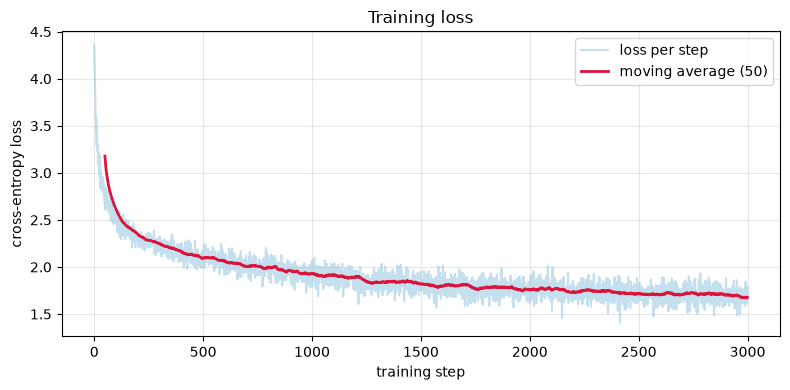

In [8]:
import numpy as np

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color="#9ecae1", alpha=0.6, label="loss per step")
w = 50
ma = np.convolve(loss_history, np.ones(w) / w, mode="valid")
plt.plot(range(w - 1, len(loss_history)), ma, color="crimson", lw=2, label=f"moving average ({w})")
plt.xlabel("training step"); plt.ylabel("cross-entropy loss")
plt.title("Training loss"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Generate text

Start from a single newline token and let the model write 500 characters, sampling one at a
time. It is a tiny model trained briefly, so expect Shakespeare-flavored gibberish: made-up
names, colons for speakers, and roughly word-shaped tokens. That structure is exactly what
the model learned from the data.

In [9]:
context = torch.zeros((1, 1), dtype=torch.long)   # a single starting token
generated = model.generate(context, max_new_tokens=500)[0].tolist()
print(decode(generated))


Then, and and wit that soul
Mroon his lence he rith never shampy at an was and hear love; but you. Lon upon,
Even:
Here there be these the rewellking so.

LUCENLY BOLINGBROKE:
Upon it, you widing wit malse overeen at persing metor: hore flows' seek, the she the gine;
But Lrown thee lord, cy then, gented, befceshice
By royas a mowidine deads vour eitle us.

ALINA:
Not their mind couble one:
The this jus, but sonsepents; I hom! O, what for feam, perdon come dread the eart be hear grevot greather l


## Recap

You just built and trained a complete, if tiny, language model:

- **Embedding** turns character ids into vectors.
- Each **block** mixes tokens with **MLA** (latent attention + RoPE) and transforms them
  with a **Sparse MoE** feed-forward, both wrapped in pre-LayerNorm and residuals.
- A final **LayerNorm** and **Linear head** produce next-character logits.
- Training minimizes **cross-entropy**, and **sampling** turns the model into a generator.

This is the same skeleton as a real DeepSeek-style model, just scaled down. To make it
stronger: more layers and width, a larger `block_size`, more experts, longer training, and
a proper load-balancing loss on the router.